
# Inversion with structural constraints

In [2]:
%matplotlib widget

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pygimli as pg
import pygimli.meshtools as mt
from pygimli.physics import ert
import os

First we load the data and the interface

In [4]:
os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/line01/new_ball_asf", exist_ok=True)

filename = r'data\line01\og_fromtomsnotes_mytopo\project_5\Dipole-Dipole_1-2018-06-11-161704.dat'
data = ert.load(filename)
print(data)

02/03/26 - 12:27:40 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas
Data: Sensors: 81 data: 1469, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


In [5]:
xs = np.array([s.x() for s in data.sensors()])  # an array of all elec x-positions along line

data_min = xs.min(); data_max = xs.max()

print(data_min, data_max)

0.0 400.0


adding "topo = topo[np.argsort(topo[:,0])]"  to deal w negative vals


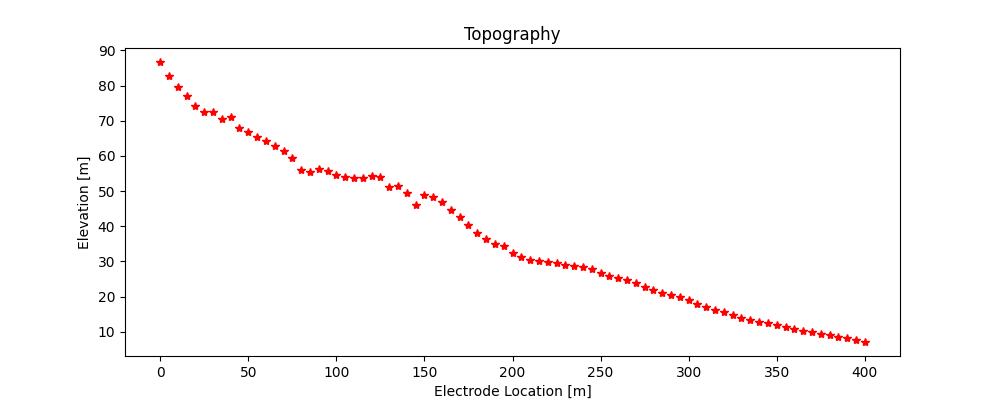

In [6]:
topo = []

topo_file = r'data\line01\og_fromtomsnotes_mytopo\line01_mytopo.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

x_elec = pg.x(data)  # get x pos of all electrodes
z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))

# print(f'x elec: {x_elec}')
# print(f'topo[:,0]: {topo[:,0]}')
# print(f'topo[:,1]: {topo[:,1]}')


# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# print(f'z interp: {z_interp}')

# set electrode positions in data
data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# plot to check
fig, ax = plt.subplots(figsize=(10,4)) 
ax.plot(x_elec, z_interp, 'r*')
ax.set_xlabel('Electrode Location [m]')
ax.set_ylabel('Elevation [m]')
ax.set_title('Topography')

plt.show()

K should convert measured resistance from the field to true resistivity.
- Analytical: assumes flat ground and ideal geometry, so less accurate.
- Numerical: solves with PDE and uses real electrode positions and topography.

In [7]:
# topo= pg.PosVector(topo)  # turn from array into pygimli pos vector

k0 = ert.createGeometricFactors(data)  # analytical; assumes simple geometry
data['k'] = ert.createGeometricFactors(data, numerical=True)  # numerical; solves forward PDE

02/03/26 - 12:27:48 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 6): C:\Users\sydne\AppData\Roaming\pygimli\Cache\12980310372855868539
02/03/26 - 12:27:48 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (6.2s x 6): C:\Users\sydne\AppData\Roaming\pygimli\Cache\15520836945033279526


Now we shall observe the topography effect, i.e the ratio between
the numerically computed geometry factor and the analytical formula after
Rücker et al. (2006). We display it using a colormap with neutral white.

from chat: "Topographic effect on resistivity
- ~1: topo has little effect
- topo > 1: ignoring topo overestimates resistivity
- topo < 1: ignoring topo underestimates resistivity"

bwr colormap directory:
- blue: high numerical k
- red: high analytical k
- white: same

Pseudo-depth: sensitivity location.
- DD: dipole dipole.
- Numbers: electrode spacing levels. 
    - Current: controls how deep the current penetrates (A-B)
    - Potential: controls voltage sensitivity (M-N).
- ex. DD2-3:
    - current dipole spacing: 2 electrodes.
    - potential dipole spacing: 3 electrodes. 

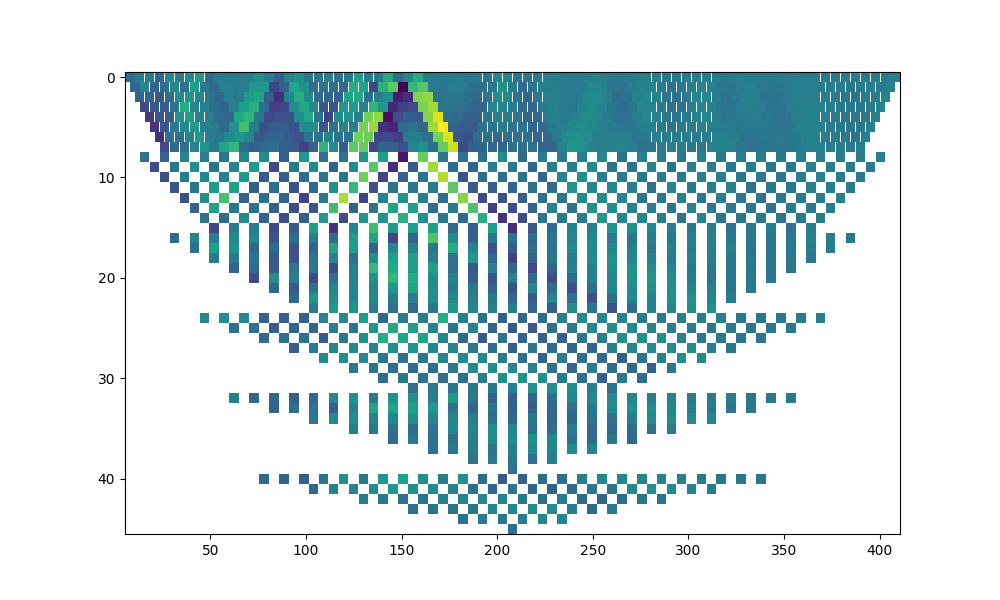

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
_ = ert.showData(data, 
                 vals=k0/ data['k'],  # quantifies the topography effect
                 ax=ax,
                 label='Topography effect', xlabel='Distance [m]', ylabel='Pseudo-depth',
                 cMin=2/3, cMax=3/2,  # color limits
                 logScale=True, 
                 cMap="bwr"  # blue-white-red colormap
)

ax.set_title('Topography Effect on Data');

fig.savefig(r"figures/line01/new_ball_asf/1topo_effect_on_data.png", dpi=300, bbox_inches='tight')


If the topography effect on data looks strange (ie. no color bar, axes titles) just rerun and it'll work!!!


We can now compute the apparent resistivity and display it, once with the
wrong analytical formula and once with the numerical values.

 Min: 13.35524259282989, Max: 2480.1898550472188


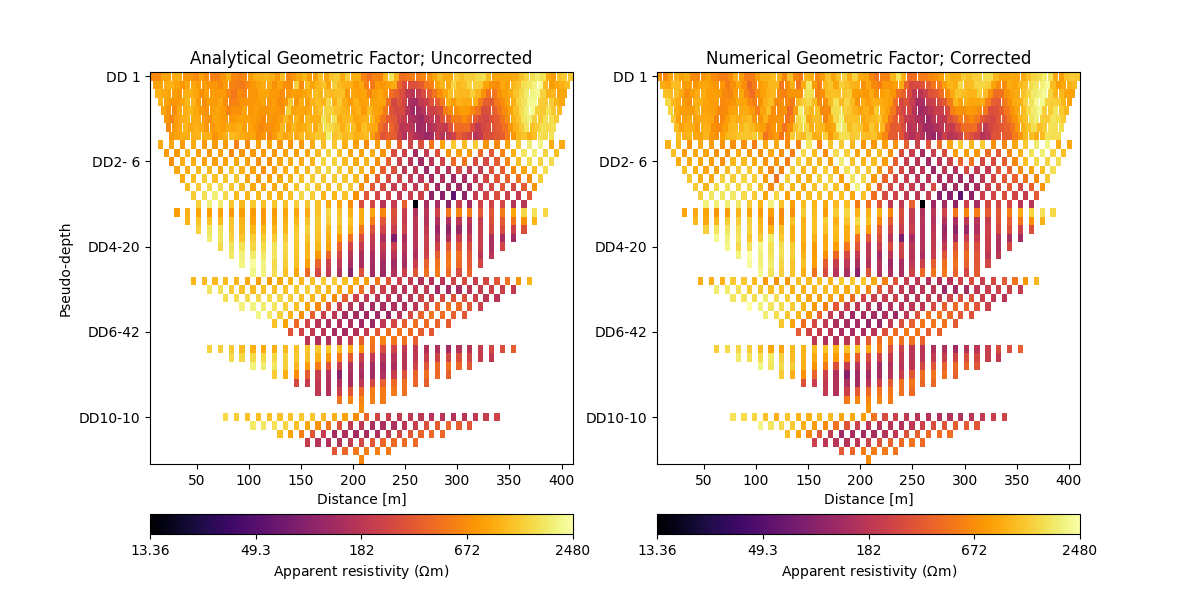

In [13]:
data['rhoa'] = data['r'] * data['k']  # uses numerical k; converts measured resistances to apparent resist

# edit impossible negative or zero values
data['rhoa'][data['rhoa'] <= 0] = 1e-6

cmin = pg.min(data['rhoa'])
cmax = pg.max(data['rhoa'])
print(f' Min: {pg.min(data["rhoa"])}, Max: {pg.max(data["rhoa"])}')

kw = dict(cMin=cmin, cMax=cmax)  # storing key/value pairs for colour scale
fig, ax = plt.subplots(ncols=2, figsize=(12, 6))

data.show(data['r']*k0, ax=ax[0], **kw, cMap='inferno', 
          xlabel='Distance [m]', ylabel='Pseudo-depth');  # uses analytical k so assumes flat ground

data.show(ax=ax[1], **kw, cMap='inferno',
          xlabel='Distance [m]')  # uses numerical k so adds topo

ax[0].set_title('Analytical Geometric Factor; Uncorrected')  # analytical
ax[1].set_title('Numerical Geometric Factor; Corrected');  # numerical 

fig.savefig(r"figures/line01/new_ball_asf/2uncorrected_vs_corrected_geometric.png", dpi=300, bbox_inches='tight')

We estimate an error and do a normal inversion using the ERT manager.
As we expect more or less layered structures, we choose a vertical
weighting factor for the regularization of 0.5.




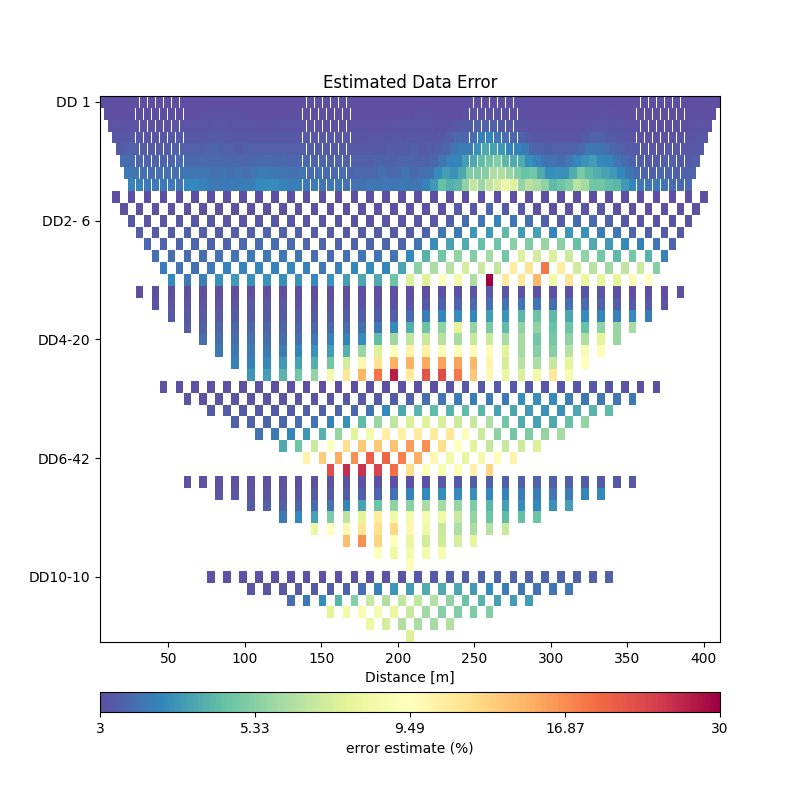

In [14]:
data.estimateError(relativeError=0.03, absoluteUError=5e-5)

fig, ax = plt.subplots(figsize=(8,8))
_ = data.show( data['err']*100, ax=ax,
    label='error estimate (%)', xlabel='Distance [m]',
    cMin=3, cMax=30)

ax.set_title('Estimated Data Error');

fig.savefig(r"figures/line01/new_ball_asf/3est_data_error.png", dpi=300, bbox_inches='tight')

code for storing the points

In [15]:
def onclick(event):
    # make sure click is inside the correct axes
    if event.inaxes != ax:
        return

    if event.xdata is not None and event.ydata is not None:
        x_line.append(event.xdata)
        z_line.append(event.ydata)

        ax.plot(event.xdata, event.ydata, 'ro', markersize=5)  # plot on SAME axes
        fig.canvas.draw_idle()

        print(f"Picked point: x={event.xdata:.2f}, z={event.ydata:.2f}")


> Now the data have all necessary fields ('rhoa', 'err' and 'k') so we can run
the inversion!! First we run this bad boy so we can figure out how we would like to constrain...

From chat:

**lam**: controls smoothness [1 – 50]
- higher → smoother, less structure
- lower → sharper, more detail (risk of noise)

**paraDX**: horizontal cell size (m) [0.25 – 1 × electrode spacing]
- smaller → higher resolution
- larger → faster, smoother
- *note*: don’t go smaller than electrode spacing

**paraMaxCellSize**: max cell size at depth and controls mesh coarsening downward [5 – 20]

**paraDepth**: max inversion depth (m) [0.2 – 0.3 × line length]

**quality**: data quality [10 - 40]

02/03/26 - 12:28:47 - pyGIMLi - INFO - Found 2 regions.
02/03/26 - 12:28:47 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)


Directory: C:\Users\sydne\git\erth370\erth370-w2026-sydpas\pygimex\ert\extra_files\line01


02/03/26 - 12:28:48 - pyGIMLi - INFO - Found 2 regions.
02/03/26 - 12:28:48 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
02/03/26 - 12:28:48 - pyGIMLi - INFO - Creating forward mesh from region infos.
02/03/26 - 12:28:48 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
02/03/26 - 12:28:48 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 13339 Cells: 26080 Boundaries: 19858
02/03/26 - 12:28:49 - pyGIMLi - INFO - Use median(data values)=722.6199446081569
02/03/26 - 12:28:49 - pyGIMLi - INFO - Created startmodel from forward operator:5052, min/max=722.619945/722.619945
02/03/26 - 12:28:49 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000002B6449AB560>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 13.36/2480
min/max (error): 3%/77.34%
min/max (start model): 723/723
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  356.47
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  129.76 (dPhi = 63.21%) lam: 25.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   53.15 (dPhi = 58.16%) lam: 25.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   28.17 (dPhi = 45.32%) lam: 25.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    6.88 (dPhi = 69.75%) lam: 25.0
--------------------------------------------------

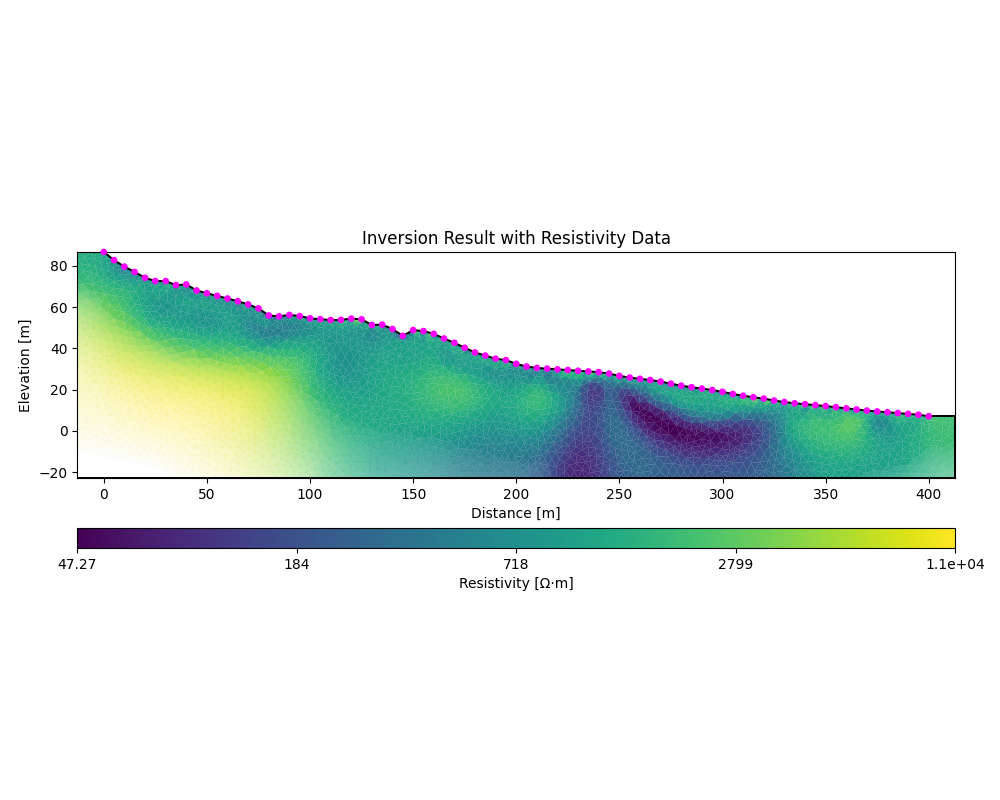

In [16]:
# initializing ERT manager
mgr = ert.ERTManager(data)

os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas\pygimex\ert\extra_files\line01')
print(f'Directory: {os.getcwd()}')

mod = mgr.invert(data, lam=10, verbose=True,
                 paraDX=0.3, paraMaxCellSize=10, paraDepth=30, quality=33)

os.chdir(r'C:\Users\sydne\git\erth370\erth370-w2026-sydpas')
print(f'Directory: {os.getcwd()}')

fig, ax = plt.subplots(figsize=(10, 8))
ax, cb = mgr.showResult(ax=ax, cMap = 'viridis')
cb.set_label("Resistivity [Ω·m]") 

ax.set_title("Inversion Result with Resistivity Data")
ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")

fig.savefig(r"figures\line01\new_ball_asf\4inversion_result.png", dpi=300, bbox_inches="tight")

adding so we can see with rms and X^2 val move up

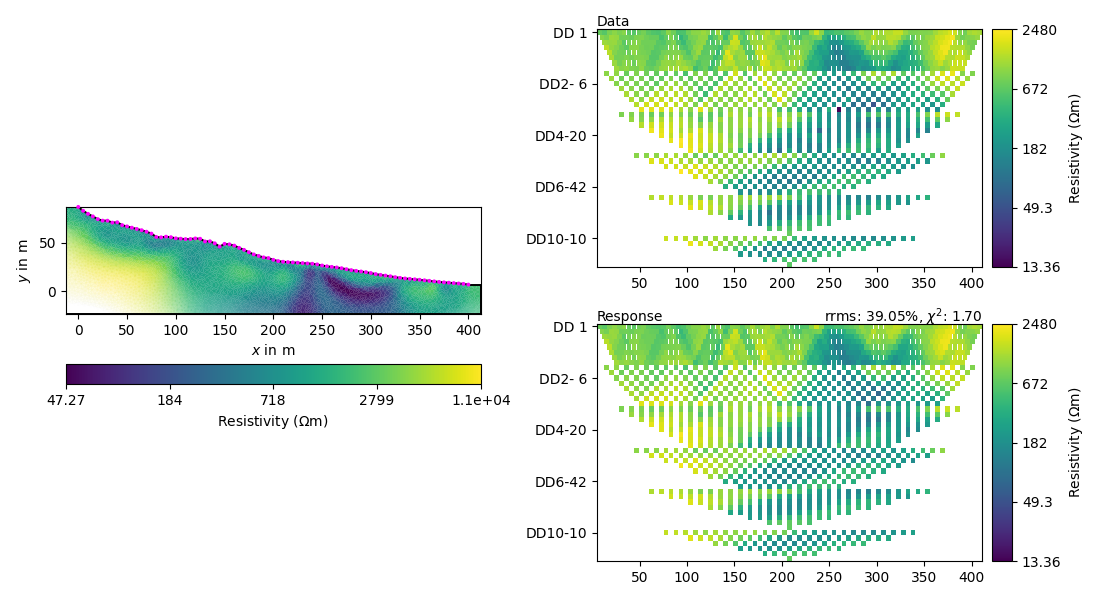

In [17]:
ax = mgr.showResultAndFit(cMap = 'viridis')
fig = ax.figure

fig.savefig(r"figures\line01\new_ball_asf\5inver_data_response.png",dpi=300,bbox_inches="tight")

now this is for after we invert that we can constrain manually for testing. better to constrain at low values!

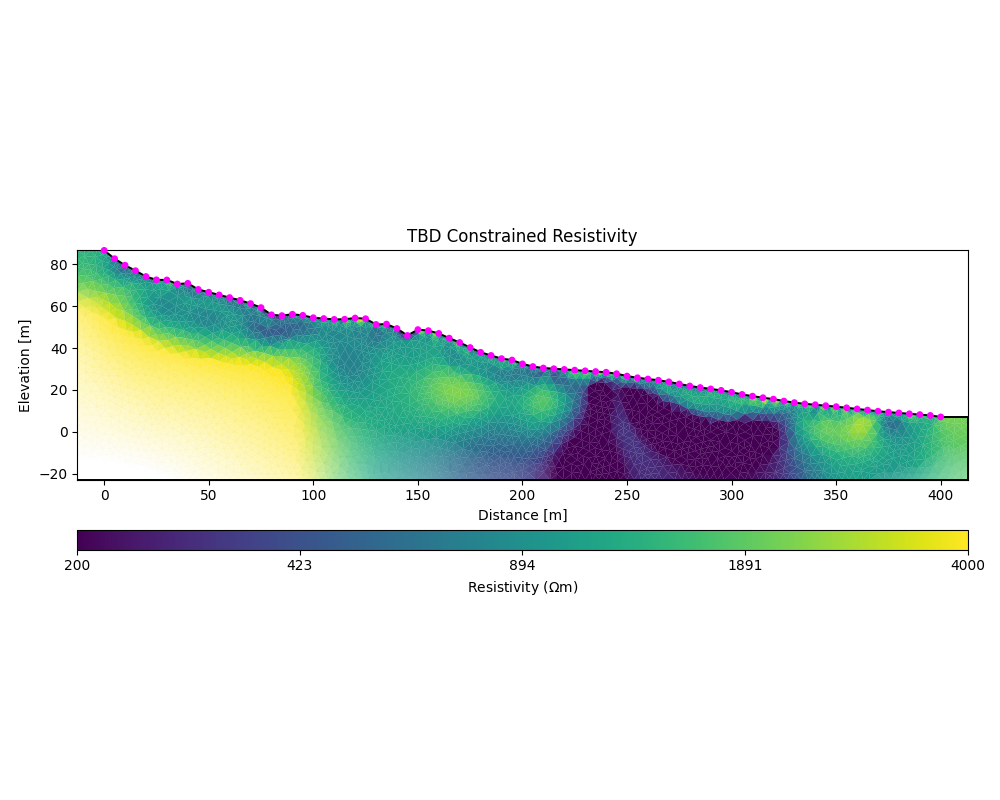

In [20]:
# lists to store clicked points
x_line = []
z_line = []

fig, ax = plt.subplots(figsize=(10,8))

ax, cb = mgr.showResult(mod, ax=ax, cMin=200, cMax=4000, cMap='viridis',logScale=True)

ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")
ax.set_title('TBD Constrained Resistivity')

# connect click handler to the SAME figure
cid = fig.canvas.mpl_connect('button_press_event', onclick)

fig.savefig(r"figures/line01/new_ball_asf/6constr_inver.png", dpi=300, bbox_inches='tight')

now re inverting with the resist contrains

In [21]:
fig.canvas.mpl_disconnect(cid)

plt.ion()

print(x_line)
print(z_line)

[322.75948426356285, 314.1531253017155, 305.546766339868, 294.0716210574046, 282.1183447215054, 272.555723652786, 263.9493646909385, 251.03982624816732, 239.086549912268, 233.34897727103638, 226.17701146949682, 212.78934197328962, 199.40167247708246, 190.795313515235, 186.49213403431125, 174.538857698412, 165.45436768312854, 156.84800872128108, 130.55080078230267, 118.11939339296742, 107.60051021737607, 101.86293757614445, 93.25657861429696, 85.60648175932144, 77.00012279747396, 70.78441910280634, 55.96235644629125, 46.39973537757183, 40.66216273634019, 31.09954166762077]
[6.943612181293588, 7.1050591908961565, 5.670666030588251, 7.583190244332144, 11.408238671819902, 15.23328709930766, 19.058335526795418, 20.49272868710335, 21.927121847411257, 22.883383954283204, 22.883383954283204, 23.839646061155122, 26.230301328334974, 29.577218702386773, 30.05534975582276, 33.40226712987456, 36.27105345049037, 38.183577664234264, 39.13983977110618, 39.13983977110618, 41.530495038286034, 48.2243297

We now want to include this line into the inversion mesh.
Therefore we generate the geometry of the inversion, a polygone from the line
and merge both objects before we send it to the mesh generation.

For line = mt.createPolygon...
- if 1: boundary contraint
- if >1: internal structure (bedrock)
- to clip for fault:
    xmin, xmax = 0, 200
    xz_clip = xz[(xz[:, 0] >= xmin) & (xz[:, 0] <= xmax)]
    line = mt.createPolygon(xz_clip, marker=2)


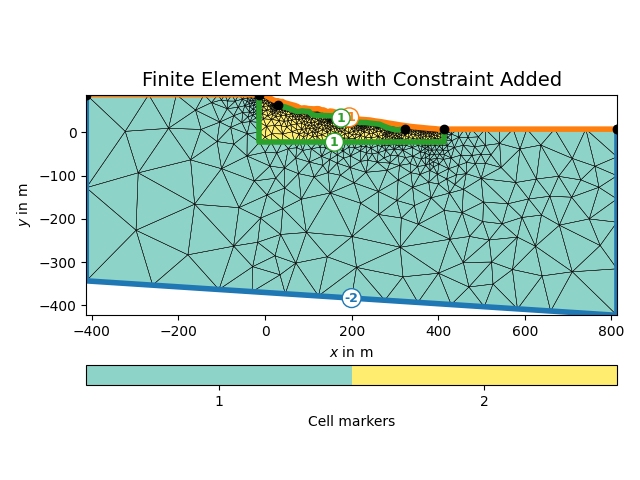

In [22]:
xz = np.column_stack([x_line, z_line])

# make sure line in domain
xmin, xmax = data.sensorPositions()[:,0].min(), data.sensorPositions()[:,0].max()
xz = xz[(xz[:, 0] >= xmin) & (xz[:, 0] <= xmax)]
xz[:, 1] -= 0.5  # ensure not to hit the surface

# build a piecewise linear complex (PLC) for meshing based on electrode pos
plc = mt.createParaMeshPLC(data, paraDepth=30, boundary=1)

# turn the xz points into polyline from topography or structure
line = mt.createPolygon(xz, marker=2)

plc += line

# generates the finite element mesh
mesh = mt.createMesh(plc, quality=34.3)  

ax, _ = pg.show(mesh, markers=True, showMesh=True)
ax.set_title('Finite Element Mesh with Constraint Added', fontsize=14);


We see the outer boundaries have markers of -1 (homogeneous Neumann, no-flow)
and -2 (mixed) important to define the boundary conditions of the forward
problem. The interface between the inversion domain (yellow) and the outer
region (blue) and the added interface are >0 and do not affect the forward.
We now use the generated mesh in a new ERT manager by setting it.




02/03/26 - 12:44:58 - pyGIMLi - INFO - Found 2 regions.
02/03/26 - 12:44:58 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
02/03/26 - 12:44:58 - pyGIMLi - INFO - Creating forward mesh from region infos.
02/03/26 - 12:44:58 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
02/03/26 - 12:44:59 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 5087 Cells: 9752 Boundaries: 7524
02/03/26 - 12:44:59 - pyGIMLi - INFO - Use median(data values)=722.6199446081569
02/03/26 - 12:44:59 - pyGIMLi - INFO - Created startmodel from forward operator:1841, min/max=722.619945/722.619945
02/03/26 - 12:44:59 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x000002B6EC3C7920>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 13.36/2480
min/max (error): 3%/77.34%
min/max (start model): 723/723
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  356.35
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  136.18 (dPhi = 61.47%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   53.34 (dPhi = 60.43%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   28.14 (dPhi = 46.14%) lam: 20.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    8.11 (dPhi = 68.35%) lam: 20.0
--------------------------------------------------

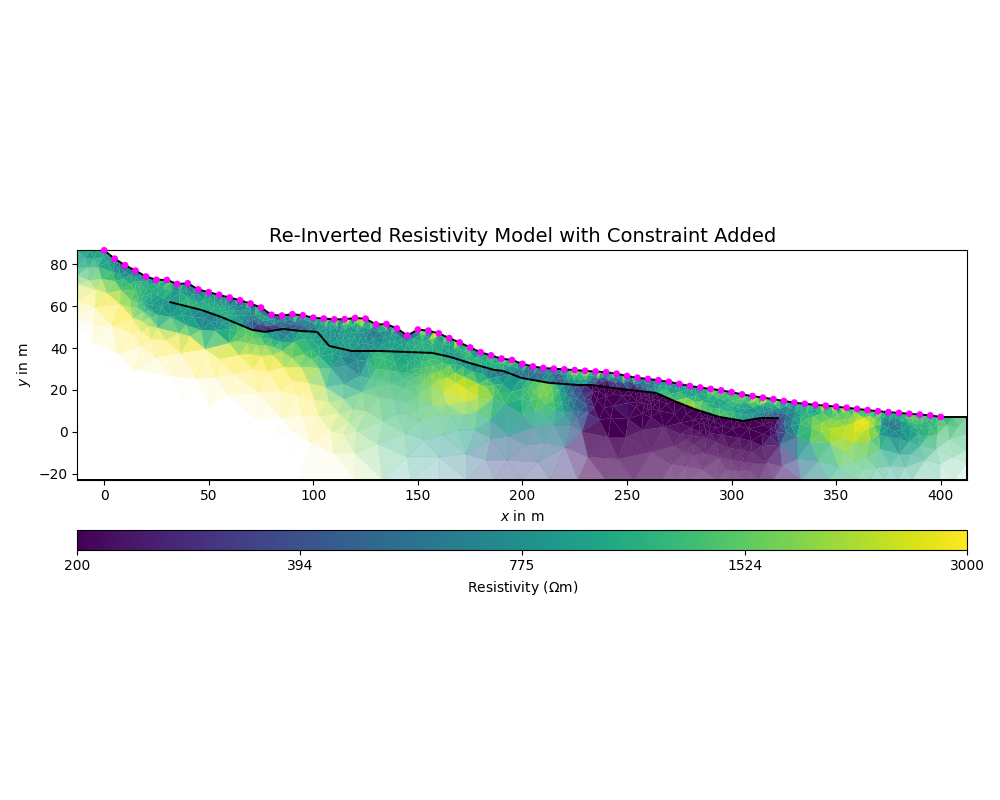

In [23]:
mgr = ert.Manager(data)
mgr.setMesh(mesh)
mod = mgr.invert(verbose=True)

fig, ax1 = plt.subplots(figsize=(10,8))

ax, cb = mgr.showResult(mod, ax=ax1, cMin=200, cMax=3000, cMap='viridis',logScale=True)

ax1.set_title('Re-Inverted Resistivity Model with Constraint Added', fontsize=14)

fig.savefig(r'figures/line01/new_ball_asf/7re_re.png', dpi=300, bbox_inches='tight')